In [2]:
# prompt: import things for data science and ml

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
# Add more imports as needed for specific tasks.


In [10]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fedesoriano/company-bankruptcy-prediction")

print("Path to dataset files:", path)

100%|██████████| 4.63M/4.63M [00:00<00:00, 58.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/fedesoriano/company-bankruptcy-prediction/versions/2


In [12]:
df=pd.read_csv(path+'/data.csv')
df

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6814,0,0.493687,0.539468,0.543230,0.604455,0.604462,0.998992,0.797409,0.809331,0.303510,...,0.799927,0.000466,0.623620,0.604455,0.840359,0.279606,0.027064,0.566193,1,0.029890
6815,0,0.475162,0.538269,0.524172,0.598308,0.598308,0.998992,0.797414,0.809327,0.303520,...,0.799748,0.001959,0.623931,0.598306,0.840306,0.278132,0.027009,0.566018,1,0.038284
6816,0,0.472725,0.533744,0.520638,0.610444,0.610213,0.998984,0.797401,0.809317,0.303512,...,0.797778,0.002840,0.624156,0.610441,0.840138,0.275789,0.026791,0.565158,1,0.097649
6817,0,0.506264,0.559911,0.554045,0.607850,0.607850,0.999074,0.797500,0.809399,0.303498,...,0.811808,0.002837,0.623957,0.607846,0.841084,0.277547,0.026822,0.565302,1,0.044009


In [7]:
!pip install summarytools
from summarytools import dfSummary

In [13]:
dfSummary(df)


No,Variable,Stats / Values,Freqs / (% of Valid),Graph,Missing
1,Bankrupt?[int64],1. 02. 1,"6,599 (96.8%)220 (3.2%)","<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAJsAAAAuCAYAAAA/ZmtKAAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjAsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvlHJYcgAAAAlwSFlzAAAPYQAAD2EBqD+naQAAATpJREFUeJzt2zFqwzAYhuFfxYRmkTAGH8aH6GF7CN3GGGtoQhZ16FBTy0vdfAL1fUZP//BiSPDncs4GKDgzu5rZpfYhaM4j53zbPuiGYXjz3ve1LkKbUkqLc+59G1znve+nabqFEO41j0M71nV9jTH28zxfzOw7NjOzEMJ9HMePatehRdefD15qXIH/idggQ2yQITbIEBtkiA0yxAYZYoMMsUGG2CBDbJAhNsgQG2SIDTLEBpnO7Otjt9qHoB1HPXUppSXG2FvhYzfgt1JKi5k9ts8YvOBZdoMXx5QPKkdvtl2VwFnFKV9phgWctZvyHc2wgLOOpnz8MsWf409dyBAbZIgNMsQGGWKDDLFBhtggQ2yQITbIEBtkiA0yxAYZYoMMsUGG2CCzm/Ix68OzFKd8pRkWcBaDF8h8Agpbat9eu713AAAAAElFTkSuQmCC"">",0(0.0%)
2,ROA(C) before interest and depreciation before interest[float64],Mean (sd) : 0.5 (0.1)min < med < max:0.0 < 0.5 < 1.0IQR (CV) : 0.1 (8.3),"3,333 distinct values","<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKoAAABGCAYAAABc8A97AAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjAsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvlHJYcgAAAAlwSFlzAAAPYQAAD2EBqD+naQAAApZJREFUeJzt2L9u2lAYhvHvlD81pDpHDhLZcgOROmRk75qLzSVkYOjMHbBFQRYoBBdj3KGq1FRJEw6m8DrPb//wNzyyz8FVVWXAqft07AWA92gfe4Emcs71zKwbOb6uqmpV5z5NQKg1c871BoPBjfc+jZlfLBaZc+6WWJ8j1Pp1vffpaDRahRDyXQbn83kyHo/T2WzWNTNC/QOhHkgIIR8Oh08Ro73al2kALlOQQKiQwKf/FXvc3P12u+3Uvc9HR6gv2OfmXhRFUpblVZ7nd2YWc0bFCwj1ZdE39+l0mk4mk/5ms2kdarmPiFD/IebmnmUZt/YD4DIFCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCe1jL4DnyrLsmJl3zsX+xLqqqlWNK50EQj0hy+WyUxTF18vLy1ar1cpjfmOxWGTOudumxdrYUJ1zPTPrRo777XbbqXOf91iv1+0kSfrX19f5xcVFtuv8fD5PxuNxOpvNumZGqKfOOdcbDAY33vs0Zr4oiqQsy6s8z+/M7Knm9d50dnaWD4fD2Of2al3mRDQyVDPreu/T0Wi0CiHs/AmdTqfpZDLpbzab1iGWw+6aGqqZmYUQot5MWZY18q2k7KRD3eOceZQzJg7nzVCdc4mZff4Pu/wtOT8//xZC+LLr4O8z5sPDw/eYBz8+PiZmZsvlMrm/v+8rzJr9ukyVZdm2/f7eOpYfVVW9ekz7CSDYubJKolh7AAAAAElFTkSuQmCC"">",0(0.0%)
3,ROA(A) before interest and % after tax[float64],Mean (sd) : 0.6 (0.1)min < med < max:0.0 < 0.6 < 1.0IQR (CV) : 0.1 (8.5),"3,151 distinct values","<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKoAAABGCAYAAABc8A97AAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjAsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvlHJYcgAAAAlwSFlzAAAPYQAAD2EBqD+naQAAAm1JREFUeJzt3b1uGkEUhuFzgiGLncxoQcKdbyBSCkr6tL5Yt+lSUKTmDmgsC4RBYDb8bapISWTHYVns/fD79Gc5xdvMaCQ8z3MDqu7day8A/I+z117gFLl708waBcdXeZ4vy9znFBBqydy92W63r0MIaZH52Ww2cfcbYv0ToZavEUJIe73eMsaY7TM4nU6Tfr+fjsfjhpkR6m8I9UhijFmn03koMNosfZkTwGEKEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEvgb9IrZbrd1MwvuXvQTqzzPlyWuVAmEWiGLxaK+Xq8/X11d1Wq1WlbkG7PZbOLuN6cWK6FWyGq1OkuS5Lzb7WaXl5eTfeen02nS7/fT8XjcMDNCxXFdXFxknU7noeB4s9RlKoLDFCQQKiQQKiQQKiRwmHqCuzfNrFFgNOx2u3rZ+7x1hPoId2+22+3rEEK67+x6vU622+2nLMu+mVnRkzv+QqiPa4QQ0l6vt4wx7nXxPhwO08FgcL7ZbGrHWu4tItR/iDHufZ85mUxO8h7ztXGYggRChQRChQRChYSTPUwdcA9qJnwXeuB71sq+ZX02VHdPzOz9C+xSpqTVan2JMX4oMvzrLnQ0Gn3fd3Y+nydmZovFIrm7uzt/qVkzs9vb24+HvGe9v7+fu/tXMyv0FvZAP/I8f/J3fwLW0KDO9xwWdQAAAABJRU5ErkJggg=="">",0(0.0%)
4,ROA(B) before interest and depreciation after tax[float64],Mean (sd) : 0.6 (0.1)min < med < max:0.0 < 0.6 < 1.0IQR (CV) : 0.1 (9.0),"3,160 distinct values","<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKoAAABGCAYAAABc8A97AAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjAsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvlHJYcgAAAAlwSFlzAAAPYQAAD2EBqD+naQAAAm1JREFUeJzt2j9v2lAUhvFzCqGGtPfKIMHGF6jUISN713zYrN06eOicb5AlQkEEBMHlnztVaqqkLcYJvOT57cec4RHWta4XRWHAsXt36AWA/1E/9AKnyN2bZtYoOb4simJR5T6ngFAr5u7NTqdzGUJIy8xPp9Oxu18R62OEWr1GCCEdDAaLGGO+y+BkMkmyLEtHo1HDzAj1N4T6QmKMebfbfSgx2qx8mRPAYQoSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUSCBUS

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-tax net Int

In [20]:
# prompt: pivottablejs

!pip install pivottablejs
from pivottablejs import pivot_ui


In [21]:
pivot_ui(df)


In [24]:
(df.isna().sum() > 0).sum()

0

In [28]:
df.columns = [c.replace(' ', '_') for c in df.columns]
df

,Bankrupt?,_ROA(C)_before_interest_and_depreciation_before_interest,_ROA(A)_before_interest_and_%_after_tax,_ROA(B)_before_interest_and_depreciation_after_tax,_Operating_Gross_Margin,_Realized_Sales_Gross_Margin,_Operating_Profit_Rate,_Pre-tax_net_Interest_Rate,_After-tax_net_Interest_Rate,_Non-industry_income_and_expenditure/revenue,...,_Net_Income_to_Total_Assets,_Total_assets_to_GNP_price,_No-credit_Interval,_Gross_Profit_to_Sales,_Net_Income_to_Stockholder's_Equity,_Liability_to_Equity,_Degree_of_Financial_Leverage_(DFL),_Interest_Coverage_Ratio_(Interest_expense_to_EBIT),_Net_Income_Flag,_Equity_to_Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6814,0,0.493687,0.539468,0.543230,0.604455,0.604462,0.998992,0.797409,0.809331,0.303510,...,0.799927,0.000466,0.623620,0.604455,0.840359,0.279606,0.027064,0.566193,1,0.029890
6815,0,0.475162,0.538269,0.524172,0.598308,0.598308,0.998992,0.797414,0.809327,0.303520,...,0.799748,0.001959,0.623931,0.598306,0.840306,0.278132,0.027009,0.566018,1,0.038284
6816,0,0.472725,0.533744,0.520638,0.610444,0.610213,0.998984,0.797401,0.809317,0.303512,...,0.797778,0.002840,0.624156,0.610441,0.840138,0.275789,0.026791,0.565158,1,0.097649
6817,0,0.506264,0.559911,0.554045,0.607850,0.607850,0.999074,0.797500,0.809399,0.303498,...,0.811808,0.002837,0.623957,0.607846,0.841084,0.277547,0.026822,0.565302,1,0.044009


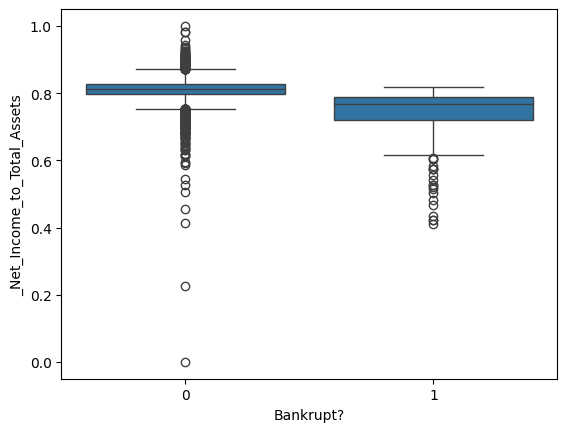

In [29]:
sns.boxplot(y='_Net_Income_to_Total_Assets', x='Bankrupt?', data=df)
plt.show()

KeyError: 'Net Income to Total Assets'

In [37]:
target = "Bankrupt?"
X = df.drop(columns=[target])
y = df[target].values.reshape(-1,1)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (6819, 95)
y shape: (6819, 1)


In [38]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.25 , random_state=42)

In [40]:
# prompt: RandomOverSampler

from imblearn.over_sampling import RandomOverSampler

oversampler = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = oversampler.fit_resample(X_train, y_train)

print("X_train_resampled shape:", X_train_resampled.shape)
print("y_train_resampled shape:", y_train_resampled.shape)


X_train_resampled shape: (9904, 95)
y_train_resampled shape: (9904,)


In [42]:
# prompt: randomforest classifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Initialize and train the RandomForestClassifier
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train_resampled, y_train_resampled.ravel())

# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1647
           1       0.62      0.31      0.41        58

    accuracy                           0.97      1705
   macro avg       0.80      0.65      0.70      1705
weighted avg       0.96      0.97      0.97      1705

Accuracy: 0.9700879765395894


In [43]:
rf_classifier.score(X_train_resampled,y_train_resampled)

1.0

In [45]:
rf_classifier.score(X_test,y_test)

0.9700879765395894

In [46]:
rf_classifier.score(X,y)

0.9925208974923009

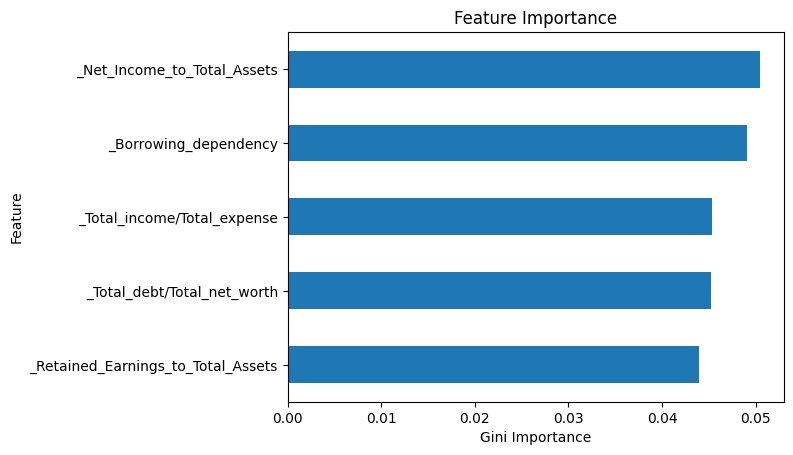

In [50]:
# prompt: feature_importances
features = X_test.columns
importances = rf_classifier.feature_importances_
feat_imp = pd.Series(importances , index=features).sort_values()
feat_imp.tail().plot(kind= 'barh')
plt.xlabel("Gini Importance")
plt.ylabel("Feature")
plt.title("Feature Importance");


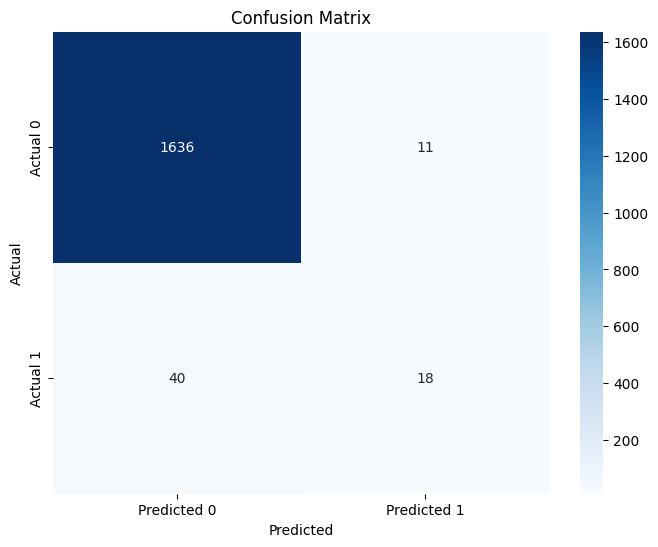

In [51]:
# prompt: confusion matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming y_test and y_pred are already defined from your previous code

cm = confusion_matrix(y_test, y_pred)

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted 0", "Predicted 1"],
            yticklabels=["Actual 0", "Actual 1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [58]:
target = "Bankrupt?"
X = df.drop(columns=[target])
y = df[target].values.reshape(-1,1)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (6819, 95)
y shape: (6819, 1)


In [59]:
# prompt: oversampling

# Assuming X_train, y_train, X_test, and y_test are already defined from your previous code.
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("X_train_resampled shape:", X_resampled.shape)
print("y_train_resampled shape:", y_resampled.shape)


X_train_resampled shape: (13198, 95)
y_train_resampled shape: (13198,)


In [61]:
# prompt: split data

# Assuming X and y are already defined from your previous code.

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.25, random_state=42)


In [63]:
# prompt: random forest classifier

# Initialize and train the RandomForestClassifier
rf_classifier = RandomForestClassifier(random_state=42) # Example hyperparameters
rf_classifier.fit(X_train, y_train.ravel())

# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
print(classification_report(y_test, y_pred))
print("Accuracy test:", rf_classifier.score(X_test, y_test))
print("Accuracy train:", rf_classifier.score(X_train, y_train))
print("Accuracy all:", rf_classifier.score(X_resampled, y_resampled))


              precision    recall  f1-score   support

           0       1.00      0.97      0.98      1666
           1       0.97      1.00      0.98      1634

    accuracy                           0.98      3300
   macro avg       0.98      0.98      0.98      3300
weighted avg       0.98      0.98      0.98      3300

Accuracy test: 0.9821212121212122
Accuracy train: 1.0
Accuracy all: 0.9955296257008638


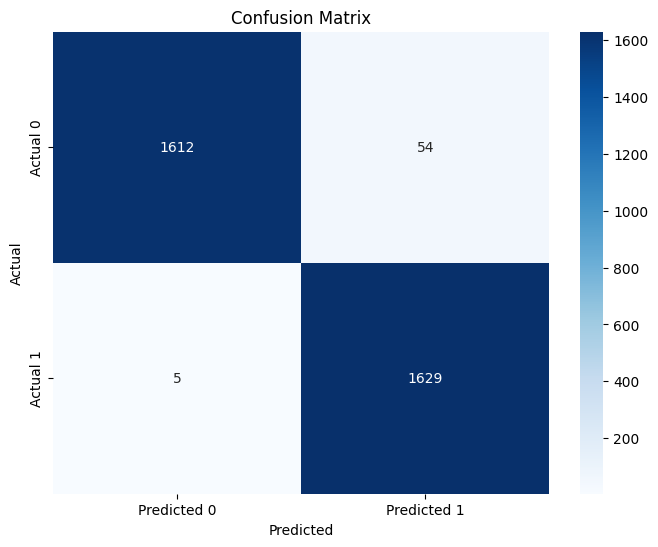

In [64]:
# prompt: confusion matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming y_test and y_pred are already defined from your previous code

cm = confusion_matrix(y_test, y_pred)

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted 0", "Predicted 1"],
            yticklabels=["Actual 0", "Actual 1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
